# 06 — Forward Test (Baseline + Enhanced)

Out-of-sample 2025 forward test comparing the baseline strategy (single-period RF, equal weight) with enhanced strategies (probability thresholds, transaction costs, confidence-weighted positions, bootstrap CIs).

**Part A — Setup & Data Loading** (shared)  
**Part B — BASELINE Forward Test** (old model, equal weight, no costs)  
**Part C — ENHANCED Forward Test** (new model, probability thresholds, costs, confidence weighting, sector caps, top-N)  
**Part D — Side-by-Side Comparison**

In [1]:
from __future__ import annotations

import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.backtest import (
    build_oos_features,
    compare_insample_oos,
    compute_oos_returns,
    evaluate_forward,
    bootstrap_winner_portfolio_metrics,
    plot_cumulative_returns,
    plot_hit_rates,
    plot_insample_vs_oos,
    plot_oos_confusion_matrix,
    strategy_summary,
)
from src.classifier import assign_groups
from src.data_loader import download_ohlcv, load_fundamentals
from src.features import (
    build_feature_matrix,
    build_rank_features,
    build_sector_dummies,
    drop_correlated_features,
    audit_fundamental_coverage,
)
from src.model import load_model, plot_confusion_matrix, predict, predict_proba, predict_with_threshold
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 140)

print(f"Project root: {PROJECT_ROOT}")
print(f"OOS year: {config.OOS_YEAR}")
print(f"OOS feature cutoff: {config.OOS_FEATURE_CUTOFF_DATE}")

Project root: /Users/stephangath/cursorAi/Stock Analysis AI
OOS year: 2025
OOS feature cutoff: 2024-12-31


## Part A — Data & Model Loading

In [2]:
tickers = get_spi_extra_tickers()
ohlcv = download_ohlcv(tickers, start=config.YF_START, end=config.YF_END, cache_dir=config.DATA_DIR)
liquid_tickers = filter_by_min_volume(ohlcv, config.MIN_DAILY_VOLUME_CHF)
liquid = {t: ohlcv[t] for t in liquid_tickers if t in ohlcv}
print(f"Liquid tickers: {len(liquid)}")

fundamentals: dict[str, dict] = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {pool.submit(load_fundamentals, t, cache_dir=config.DATA_DIR): t for t in liquid}
    for fut in as_completed(futs):
        t = futs[fut]
        try:
            fundamentals[t] = fut.result()
        except Exception:
            pass
print(f"Fundamentals: {len(fundamentals)} tickers")

$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$BALN.SW: possibly delisted; no timezone found

1 Failed download:
['BALN.SW']: possibly delisted; no timezone found
$BLS.SW: possibly delisted; no timezone found

1 Failed download:
['BLS.SW']: possibly delisted; no timezone found
$BOBNN.SW: possibly delisted; no timezone found

1 Failed download:
['BOBNN.SW']: possibly delisted; no timezone found
$BPDG.SW: possibly delisted; no timezone found

1 Fail

Liquid tickers: 136
Fundamentals: 136 tickers


In [3]:
oos_returns = compute_oos_returns(liquid, year=config.OOS_YEAR)
print(f"\nOOS returns ({config.OOS_YEAR}): {len(oos_returns.dropna())} tickers")
print(f"  Mean: {oos_returns.mean():.3f}")
print(f"  Median: {oos_returns.median():.3f}")


OOS returns (2025): 136 tickers
  Mean: 0.113
  Median: 0.068


In [4]:
model_dir = config.DATA_DIR / "models"

baseline_model = load_model(model_dir / "baseline_classifier.joblib")
print(f"Baseline model loaded: type={baseline_model.model_type}, features={len(baseline_model.feature_names)}, calibrated={getattr(baseline_model, 'calibrated', False)}")

enhanced_model = load_model(model_dir / "enhanced_classifier.joblib")
print(f"Enhanced model loaded: type={enhanced_model.model_type}, features={len(enhanced_model.feature_names)}, calibrated={getattr(enhanced_model, 'calibrated', False)}")

Baseline model loaded: type=rf, features=28, calibrated=False
Enhanced model loaded: type=ensemble, features=54, calibrated=True


---
## Part B — BASELINE Forward Test

Original strategy: single-period RF, equal-weight long Winners, no costs.

In [5]:
X_oos_baseline = build_oos_features(liquid, fundamentals, cutoff_date=config.OOS_FEATURE_CUTOFF_DATE)
print(f"Baseline OOS features: {X_oos_baseline.shape}")

preds_baseline = predict(baseline_model, X_oos_baseline)
print(f"\nBaseline predictions:")
display(preds_baseline.value_counts())

Baseline OOS features: (136, 28)

Baseline predictions:


predicted_group
Steady     82
Losers     35
Winners    19
Name: count, dtype: int64

In [6]:
ftr_baseline = evaluate_forward(
    preds_baseline,
    oos_returns,
    liquid,
    year=config.OOS_YEAR,
    costs_bps=0.0,
)

print("=== BASELINE Strategy Summary ===")
display(strategy_summary(ftr_baseline))

=== BASELINE Strategy Summary ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,0.2853,0.2905,0.2073,1.4011,-0.1978,248
Long/Short,0.1092,0.1111,0.0716,1.5526,-0.0358,248
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


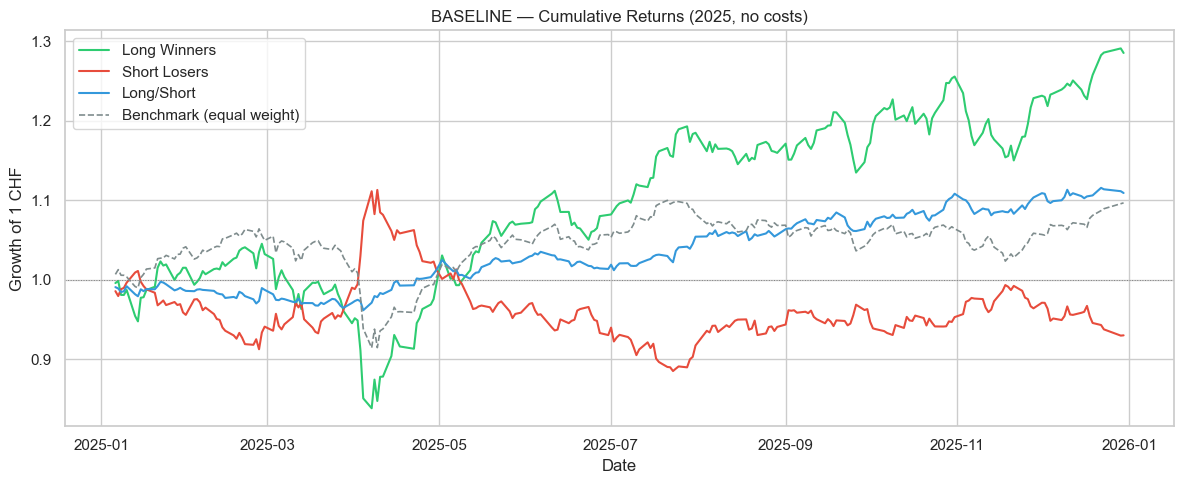

In [7]:
plot_cumulative_returns(ftr_baseline.daily_returns, title="BASELINE — Cumulative Returns (2025, no costs)")
plt.show()

=== BASELINE OOS Classification ===
Accuracy: 0.485
F1 macro: 0.421

              precision    recall  f1-score   support

      Losers       0.34      0.35      0.35        34
      Steady       0.56      0.68      0.61        68
     Winners       0.42      0.24      0.30        34

    accuracy                           0.49       136
   macro avg       0.44      0.42      0.42       136
weighted avg       0.47      0.49      0.47       136



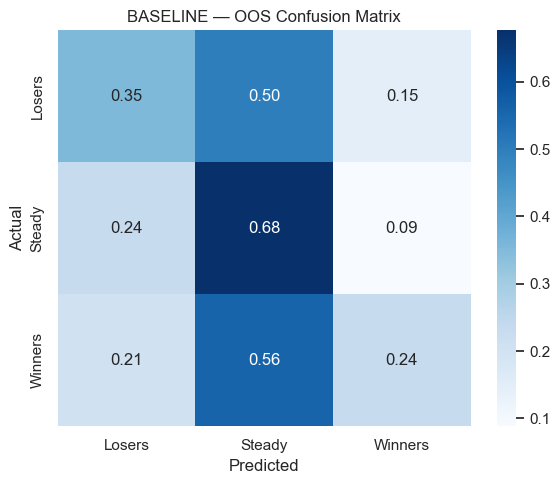

In [8]:
print("=== BASELINE OOS Classification ===")
print(f"Accuracy: {ftr_baseline.classification['accuracy']:.3f}")
print(f"F1 macro: {ftr_baseline.classification['f1_macro']:.3f}")
print(f"\n{ftr_baseline.classification['report_str']}")

plot_oos_confusion_matrix(ftr_baseline.classification, title="BASELINE — OOS Confusion Matrix")
plt.show()

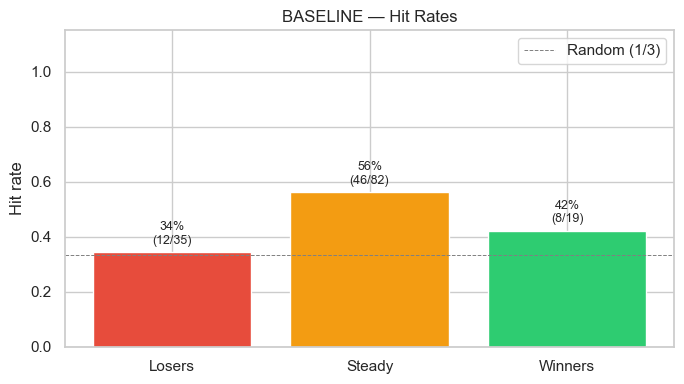

  Losers: 12/35 = 34.3%
  Steady: 46/82 = 56.1%
  Winners: 8/19 = 42.1%


In [9]:
plot_hit_rates(ftr_baseline.hit_rates, title="BASELINE — Hit Rates")
plt.show()

for group, stats in ftr_baseline.hit_rates.items():
    print(f"  {group}: {stats['n_correct']}/{stats['n_predicted']} = {stats['hit_rate']:.1%}")

=== BASELINE — In-Sample vs OOS ===


,In-Sample,Out-of-Sample,Delta
metric,,,
accuracy,0.441176,0.485294,0.044118
f1_macro,0.391721,0.421015,0.029294
f1_weighted,0.431411,0.469095,0.037684


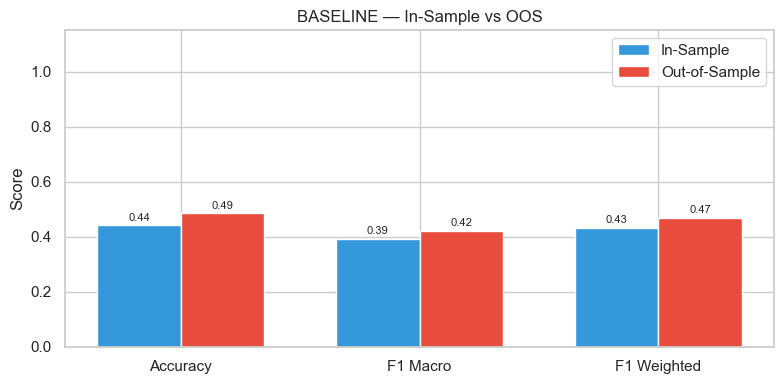

In [10]:
baseline_comparison = compare_insample_oos(baseline_model.holdout_metrics, ftr_baseline.classification)
print("=== BASELINE — In-Sample vs OOS ===")
display(baseline_comparison)

plot_insample_vs_oos(baseline_comparison, title="BASELINE — In-Sample vs OOS")
plt.show()

---
## Part C — ENHANCED Forward Test

Enhanced strategies using the multi-period model with new features.

Variants tested:
1. **Standard predict** (enhanced model, equal weight, no costs)
2. **Probability threshold** (only predict Winner if P(Winner) ≥ 0.5)
3. **With transaction costs** (40 bps one-way)
4. **Confidence-weighted** (weight by P(Winner))
5. **Top-N filter** (only top 10 Winners by probability)
6. **Full enhanced** (threshold + costs + confidence + sector caps)

In [11]:
X_oos_enhanced_raw = build_oos_features(liquid, fundamentals, cutoff_date=config.OOS_FEATURE_CUTOFF_DATE)

rank_oos = build_rank_features(X_oos_enhanced_raw)
sector_oos = build_sector_dummies(fundamentals)
X_oos_combined = pd.concat([X_oos_enhanced_raw, rank_oos, sector_oos], axis=1, join="outer").fillna(0.0)
X_oos_combined, _ = drop_correlated_features(X_oos_combined, threshold=0.85)

print(f"Enhanced OOS features: {X_oos_combined.shape}")

Enhanced OOS features: (136, 50)


In [12]:
preds_enhanced = predict(enhanced_model, X_oos_combined)
print("Enhanced predictions (standard):")
display(preds_enhanced.value_counts())

proba_enhanced = predict_proba(enhanced_model, X_oos_combined)
print(f"\nProbability matrix shape: {proba_enhanced.shape}")
display(proba_enhanced.describe())

preds_threshold = predict_with_threshold(
    enhanced_model, X_oos_combined,
    winner_class="Winners",
    winner_threshold=0.5,
)
print(f"\nThreshold predictions (P(Winner) ≥ 0.5):")
display(preds_threshold.value_counts())

Enhanced predictions (standard):


predicted_group
Steady     134
Winners      2
Name: count, dtype: int64


Probability matrix shape: (136, 3)


,Losers,Steady,Winners
count,136.000000,136.000000,136.000000
mean,0.219529,0.526003,0.254468
std,0.053674,0.073601,0.051625
min,0.146051,0.344002,0.185458
25%,0.174455,0.474721,0.216865
50%,0.207214,0.524691,0.241118
75%,0.260771,0.582252,0.277038
max,0.347497,0.663965,0.488524



Threshold predictions (P(Winner) ≥ 0.5):


predicted_group
Steady    136
Name: count, dtype: int64

In [13]:
sector_map = {}
for ticker, info in fundamentals.items():
    raw = info.get("sector") if info else None
    if raw and isinstance(raw, str) and raw.strip():
        sector_map[ticker] = raw.strip()
print(f"Sector map: {len(sector_map)} tickers")

winner_proba = proba_enhanced["Winners"] if "Winners" in proba_enhanced.columns else None

Sector map: 135 tickers


### Variant 1: Enhanced model, equal weight, no costs

In [14]:
ftr_v1 = evaluate_forward(
    preds_enhanced, oos_returns, liquid,
    year=config.OOS_YEAR, costs_bps=0.0,
)
print("=== V1: Enhanced (equal weight, no costs) ===")
display(strategy_summary(ftr_v1))

=== V1: Enhanced (equal weight, no costs) ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,0.1860,0.1893,0.2489,0.7606,-0.1687,248
Long/Short,0.1860,0.1893,0.2489,0.7606,-0.1687,248
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


### Variant 2: Probability threshold (P(Winner) ≥ 0.5)

In [15]:
ftr_v2 = evaluate_forward(
    preds_threshold, oos_returns, liquid,
    year=config.OOS_YEAR, costs_bps=0.0,
)
print("=== V2: Threshold 0.5 (no costs) ===")
display(strategy_summary(ftr_v2))

=== V2: Threshold 0.5 (no costs) ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,–,–,–,–,–,0
Long/Short,–,–,–,–,–,0
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


### Variant 3: With transaction costs (40 bps)

In [16]:
ftr_v3 = evaluate_forward(
    preds_enhanced, oos_returns, liquid,
    year=config.OOS_YEAR, costs_bps=40.0,
)
print("=== V3: Enhanced + 40bps costs ===")
display(strategy_summary(ftr_v3))

=== V3: Enhanced + 40bps costs ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,0.1766,0.1797,0.2487,0.7226,-0.1687,248
Long/Short,0.1766,0.1797,0.2487,0.7226,-0.1687,248
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


### Variant 4: Confidence-weighted positions

In [17]:
ftr_v4 = evaluate_forward(
    preds_enhanced, oos_returns, liquid,
    year=config.OOS_YEAR, costs_bps=0.0,
    proba_weights=winner_proba,
)
print("=== V4: Confidence-weighted (no costs) ===")
display(strategy_summary(ftr_v4))

=== V4: Confidence-weighted (no costs) ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,0.1768,0.1799,0.2463,0.7304,-0.1680,248
Long/Short,0.1768,0.1799,0.2463,0.7304,-0.1680,248
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


### Variant 5: Top-10 Winners by probability

In [18]:
ftr_v5 = evaluate_forward(
    preds_enhanced, oos_returns, liquid,
    year=config.OOS_YEAR, costs_bps=0.0,
    proba_weights=winner_proba,
    top_n=10,
)
print("=== V5: Top-10 Winners (no costs) ===")
display(strategy_summary(ftr_v5))

=== V5: Top-10 Winners (no costs) ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,0.1768,0.1799,0.2463,0.7304,-0.1680,248
Long/Short,0.1768,0.1799,0.2463,0.7304,-0.1680,248
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


### Variant 6: Full enhanced (threshold + costs + confidence + sector caps)

In [19]:
ftr_v6 = evaluate_forward(
    preds_threshold, oos_returns, liquid,
    year=config.OOS_YEAR,
    costs_bps=40.0,
    proba_weights=winner_proba,
    sector_map=sector_map,
    max_sector_weight=0.30,
    top_n=10,
)
print("=== V6: Full Enhanced (threshold + 40bps + confidence + sector 30% cap + top-10) ===")
display(strategy_summary(ftr_v6))

=== V6: Full Enhanced (threshold + 40bps + confidence + sector 30% cap + top-10) ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,–,–,–,–,–,0
Long/Short,–,–,–,–,–,0
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


### Equity Curves — All Strategies

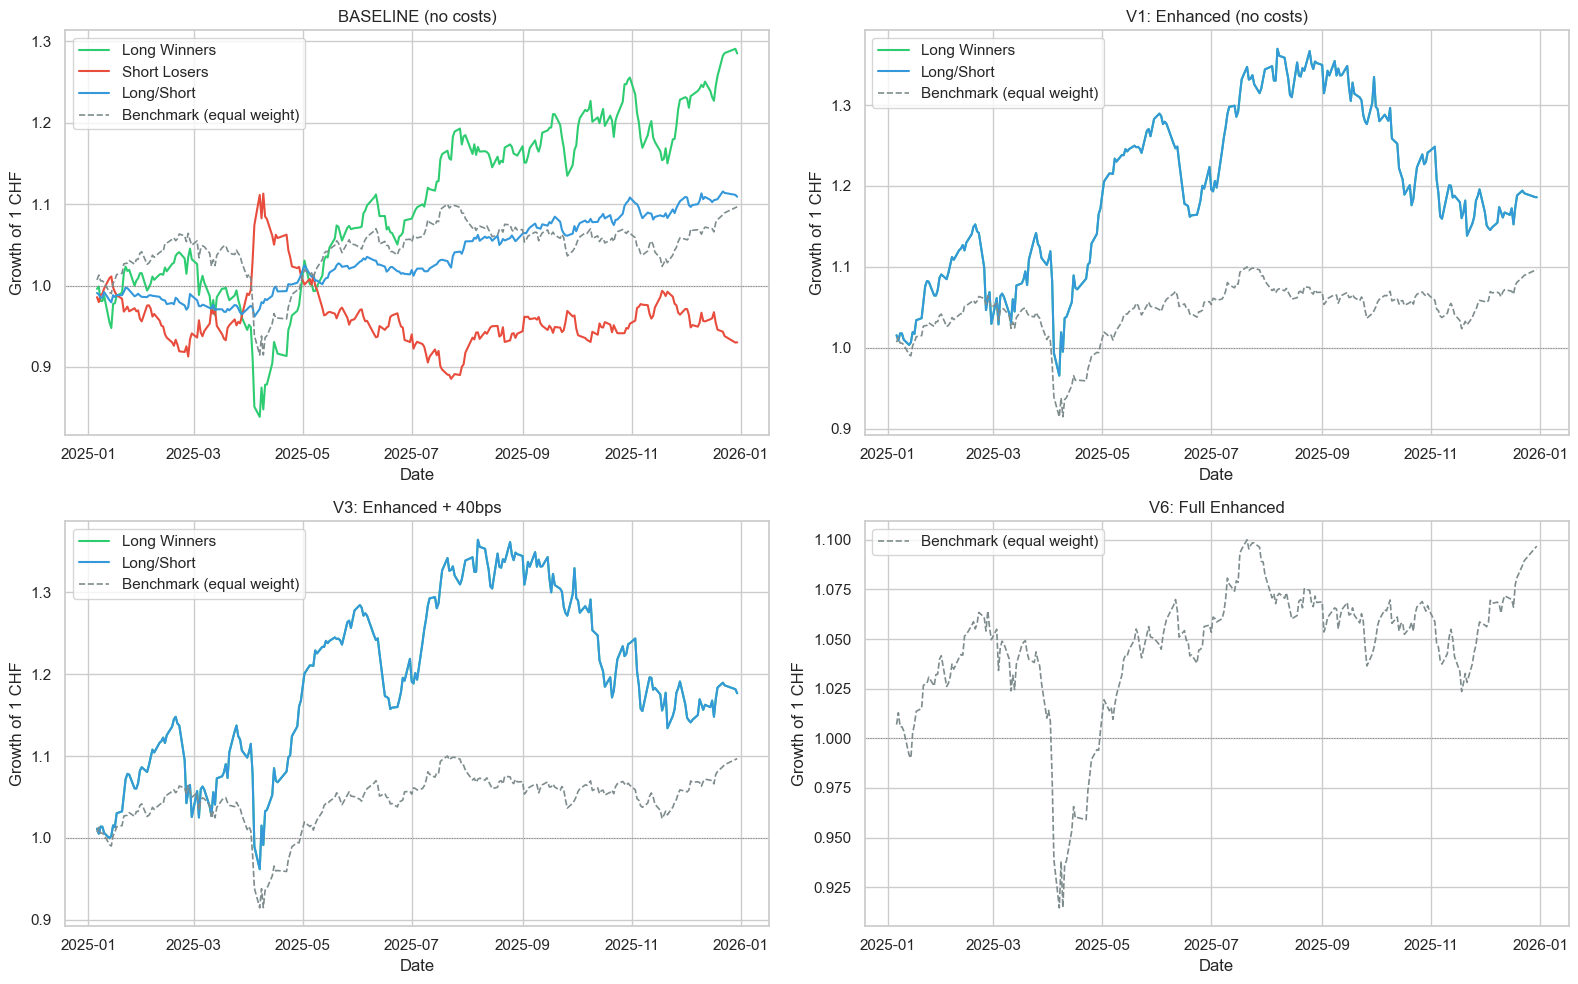

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_cumulative_returns(ftr_baseline.daily_returns, title="BASELINE (no costs)", ax=axes[0, 0])
plot_cumulative_returns(ftr_v1.daily_returns, title="V1: Enhanced (no costs)", ax=axes[0, 1])
plot_cumulative_returns(ftr_v3.daily_returns, title="V3: Enhanced + 40bps", ax=axes[1, 0])
plot_cumulative_returns(ftr_v6.daily_returns, title="V6: Full Enhanced", ax=axes[1, 1])

plt.tight_layout()
plt.show()

### Bootstrap Confidence Intervals

In [21]:
predicted_winners_baseline = list(preds_baseline[preds_baseline == "Winners"].index)
predicted_winners_enhanced = list(preds_threshold[preds_threshold == "Winners"].index)

print("=== Bootstrap CI: BASELINE Long-Winners ===")
boot_baseline = bootstrap_winner_portfolio_metrics(
    liquid, predicted_winners_baseline,
    year=config.OOS_YEAR,
    n_iterations=1000,
    costs_bps=0.0,
    random_state=config.RANDOM_SEED,
)
print(f"  Cumulative Return — p05={boot_baseline.cumulative_return['p05']:.3f}, p50={boot_baseline.cumulative_return['p50']:.3f}, p95={boot_baseline.cumulative_return['p95']:.3f}")
print(f"  Sharpe Ratio      — p05={boot_baseline.sharpe_ratio['p05']:.2f}, p50={boot_baseline.sharpe_ratio['p50']:.2f}, p95={boot_baseline.sharpe_ratio['p95']:.2f}")

print("\n=== Bootstrap CI: ENHANCED Long-Winners (threshold, 40bps) ===")
boot_enhanced = bootstrap_winner_portfolio_metrics(
    liquid, predicted_winners_enhanced,
    year=config.OOS_YEAR,
    n_iterations=1000,
    costs_bps=40.0,
    random_state=config.RANDOM_SEED,
)
print(f"  Cumulative Return — p05={boot_enhanced.cumulative_return['p05']:.3f}, p50={boot_enhanced.cumulative_return['p50']:.3f}, p95={boot_enhanced.cumulative_return['p95']:.3f}")
print(f"  Sharpe Ratio      — p05={boot_enhanced.sharpe_ratio['p05']:.2f}, p50={boot_enhanced.sharpe_ratio['p50']:.2f}, p95={boot_enhanced.sharpe_ratio['p95']:.2f}")

=== Bootstrap CI: BASELINE Long-Winners ===


bootstrap_winner_portfolio_metrics: no predicted winners


  Cumulative Return — p05=0.059, p50=0.281, p95=0.554
  Sharpe Ratio      — p05=0.26, p50=1.26, p95=2.43

=== Bootstrap CI: ENHANCED Long-Winners (threshold, 40bps) ===
  Cumulative Return — p05=nan, p50=nan, p95=nan
  Sharpe Ratio      — p05=nan, p50=nan, p95=nan


### Fundamental Data Audit

In [22]:
audit = audit_fundamental_coverage(fundamentals, min_non_nan_fraction=0.5)
n_stale = audit["likely_stale"].sum()
print(f"Fundamental coverage: {len(audit)} tickers, {n_stale} likely stale ({n_stale/len(audit):.0%})")
if n_stale > 0:
    display(audit[audit["likely_stale"]].head(20))

Fundamental coverage: 136 tickers, 1 likely stale (1%)


,n_non_nan,n_total,fraction_non_nan,empty_info,likely_stale
ticker,,,,,
ROSE.SW,0,10,0.0,False,True


---
## Part D — Side-by-Side Comparison

In [23]:
strategies = {
    "BASELINE (no costs)": ftr_baseline,
    "V1: Enhanced (no costs)": ftr_v1,
    "V2: Threshold 0.5": ftr_v2,
    "V3: Enhanced + 40bps": ftr_v3,
    "V4: Confidence-weighted": ftr_v4,
    "V5: Top-10 Winners": ftr_v5,
    "V6: Full Enhanced": ftr_v6,
}

rows = []
for name, ftr in strategies.items():
    lo = ftr.long_only
    ls = ftr.long_short
    bm = ftr.benchmark
    cls = ftr.classification

    winner_hr = ftr.hit_rates.get("Winners", {})
    rows.append({
        "Strategy": name,
        "LW Cum Return": f"{lo.get('cumulative_return', float('nan')):.1%}",
        "LW Sharpe": f"{lo.get('sharpe_ratio', float('nan')):.2f}",
        "LW MaxDD": f"{lo.get('max_drawdown', float('nan')):.1%}",
        "L/S Cum Return": f"{ls.get('cumulative_return', float('nan')):.1%}",
        "L/S Sharpe": f"{ls.get('sharpe_ratio', float('nan')):.2f}",
        "BM Cum Return": f"{bm.get('cumulative_return', float('nan')):.1%}",
        "Accuracy": f"{cls.get('accuracy', float('nan')):.1%}",
        "Winner Hit Rate": f"{winner_hr.get('hit_rate', float('nan')):.1%}",
        "N Winners": winner_hr.get("n_predicted", 0),
    })

final_comparison = pd.DataFrame(rows).set_index("Strategy")
print("=== FINAL COMPARISON ===")
display(final_comparison)

=== FINAL COMPARISON ===


,LW Cum Return,LW Sharpe,LW MaxDD,L/S Cum Return,L/S Sharpe,BM Cum Return,Accuracy,Winner Hit Rate,N Winners
Strategy,,,,,,,,,
BASELINE (no costs),28.5%,1.40,-19.8%,10.9%,1.55,9.7%,48.5%,42.1%,19
V1: Enhanced (no costs),18.6%,0.76,-16.9%,18.6%,0.76,9.7%,50.0%,50.0%,2
V2: Threshold 0.5,nan%,nan,nan%,nan%,nan,9.7%,50.0%,nan%,0
V3: Enhanced + 40bps,17.7%,0.72,-16.9%,17.7%,0.72,9.7%,50.0%,50.0%,2
V4: Confidence-weighted,17.7%,0.73,-16.8%,17.7%,0.73,9.7%,50.0%,50.0%,2
V5: Top-10 Winners,17.7%,0.73,-16.8%,17.7%,0.73,9.7%,50.0%,50.0%,2
V6: Full Enhanced,nan%,nan,nan%,nan%,nan,9.7%,50.0%,nan%,0


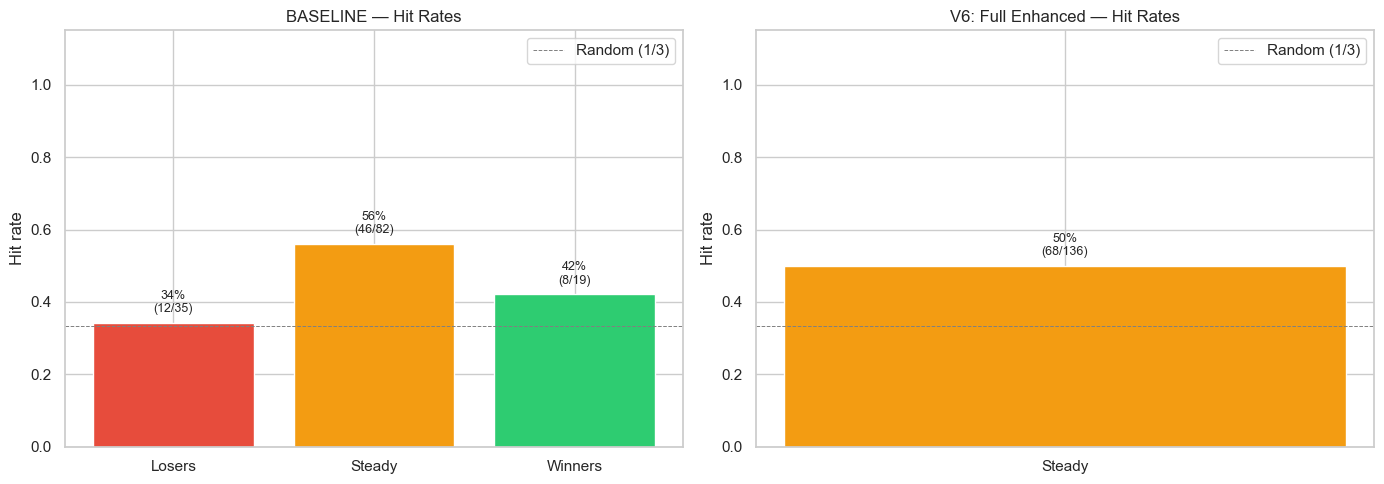

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_hit_rates(ftr_baseline.hit_rates, title="BASELINE — Hit Rates", ax=axes[0])
plot_hit_rates(ftr_v6.hit_rates, title="V6: Full Enhanced — Hit Rates", ax=axes[1])

plt.tight_layout()
plt.show()

In [25]:
print("\n=== Forward Test Complete ===")
print("Baseline and enhanced strategies compared successfully.")
print("Review the comparison table above for performance summary.")


=== Forward Test Complete ===
Baseline and enhanced strategies compared successfully.
Review the comparison table above for performance summary.


# 06 — Forward test (Out-of-Sample 2025)

**Ziel:** Q4-2024-Features (Cutoff `2024-12-31`) → Vorhersagen für 2025 mit dem finalen Modell aus Notebook 05 → Strategie-Simulation, Benchmark (Equal-Weight-Universum) und **Vergleich Hold-out (In-Sample) vs. OOS**.

**Universum:** Wie in Notebook 05 — SPI Extra nach Liquiditätsfilter (`MIN_DAILY_VOLUME_CHF`), damit Trainings- und Forward-Test dieselbe Tickerbasis nutzen.

**Ablauf:**
1. Daten & Modell laden (`data/models/final_classifier.joblib`)
2. OOS-Features berechnen (Feature-Shift, Cutoff 2024-12-31)
3. Gruppen vorhersagen (Winners / Steady / Losers)
4. Tatsächliche 2025-Returns und Perzentil-Gruppen (wie Training: `percentile`)
5. Forward-Test: Strategien, Klassifikationsmetriken, Hit-Rates
6. Equity-Kurven (Long Winners, Long/Short, Benchmark)
7. OOS Confusion Matrix & Report; optional **Hold-out vs. OOS** Fehlerstruktur
8. Hit-Rate-Analyse pro vorhergesagter Gruppe
9. **In-Sample (Hold-out) vs. Out-of-Sample** — Accuracy / F1 und Diagramm
10. Detailtabelle Predicted vs. Actual

In [26]:
from __future__ import annotations

import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.backtest import (
    build_oos_features,
    compare_insample_oos,
    compute_oos_returns,
    evaluate_forward,
    plot_cumulative_returns,
    plot_hit_rates,
    plot_insample_vs_oos,
    plot_oos_confusion_matrix,
    strategy_summary,
)
from src.classifier import assign_groups
from src.data_loader import download_ohlcv, load_fundamentals
from src.model import load_model, plot_confusion_matrix, predict
from src.universe import filter_by_min_volume, get_spi_extra_tickers

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)

print(f"Project root: {PROJECT_ROOT}")
print(f"OOS year: {config.OOS_YEAR}")
print(f"OOS feature cutoff: {config.OOS_FEATURE_CUTOFF_DATE}")

Project root: /Users/stephangath/cursorAi/Stock Analysis AI
OOS year: 2025
OOS feature cutoff: 2024-12-31


## 1 — Daten & Modell laden

In [27]:
tickers = get_spi_extra_tickers()
print(f"SPI Extra Universum: {len(tickers)} Ticker")

ohlcv = download_ohlcv(tickers, config.YF_START, config.YF_END, config.DATA_DIR)
print(f"OHLCV geladen: {len(ohlcv)} Ticker")

# Gleiches Universum wie Notebook 05 (Liquiditätsfilter)
liquid_tickers = filter_by_min_volume(ohlcv, config.MIN_DAILY_VOLUME_CHF)
liquid = {t: ohlcv[t] for t in liquid_tickers if t in ohlcv}
print(f"Nach Liquiditätsfilter: {len(liquid)} Ticker")

fundamentals: dict[str, dict] = {}
with ThreadPoolExecutor(max_workers=8) as pool:
    futs = {
        pool.submit(load_fundamentals, t, cache_dir=config.DATA_DIR): t
        for t in liquid
    }
    for fut in as_completed(futs):
        t = futs[fut]
        try:
            fundamentals[t] = fut.result()
        except Exception:
            pass
print(f"Fundamentaldaten: {len(fundamentals)} Ticker")

$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
$AFP.SW: possibly delisted; no timezone found

1 Failed download:


SPI Extra Universum: 194 Ticker


['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$BALN.SW: possibly delisted; no timezone found

1 Failed download:
['BALN.SW']: possibly delisted; no timezone found
$BLS.SW: possibly delisted; no timezone found

1 Failed download:
['BLS.SW']: possibly delisted; no timezone found
$BOBNN.SW: possibly delisted; no timezone found

1 Failed download:
['BOBNN.SW']: possibly delisted; no timezone found
$BPDG.SW: possibly delisted; no timezone found

1 Failed download:
['BPDG.SW']: possibly delisted; no timezone found
$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibl

OHLCV geladen: 154 Ticker
Nach Liquiditätsfilter: 136 Ticker
Fundamentaldaten: 136 Ticker


In [28]:
model_path = config.DATA_DIR / "models" / "final_classifier.joblib"
train_result = load_model(model_path)

print(f"Modell geladen: {train_result.model_type}")
print(f"  Features: {len(train_result.feature_names)}")
print(f"  Klassen: {train_result.class_names}")
print(f"  Best params: {train_result.best_params}")

Modell geladen: rf
  Features: 28
  Klassen: ['Losers', 'Steady', 'Winners']
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 500}


## 2 — OOS-Features berechnen (Feature-Shift)

Features werden mit Cutoff `2024-12-31` berechnet — analog zu Phase 3, aber um ein Jahr verschoben. So fliessen nur Daten bis Q4 2024 in die Features ein.

In [29]:
X_oos = build_oos_features(liquid, fundamentals)

print(f"OOS Feature-Matrix: {X_oos.shape[0]} Ticker × {X_oos.shape[1]} Features")
print(f"NaN-Rate: {X_oos.isna().mean().mean():.1%}")
X_oos.head()

OOS Feature-Matrix: 136 Ticker × 28 Features
NaN-Rate: 5.0%


,mom_1m,mom_3m,mom_6m,rsi_14,roc_10,sma_ratio_50_200,macd_diff_norm,adx_14,hvol_20d,hvol_60d,...,pe_ratio,pb_ratio,ev_ebitda,dividend_yield,revenue_growth,earnings_growth,roe,profit_margin,debt_equity,market_cap_log
ticker,,,,,,,,,,,,,,,,,,,,,
ADEN.SW,-0.033708,-0.237900,-0.258129,37.433650,-6.286672,0.835145,-0.000364,35.844599,0.228043,0.252345,...,11.60625,1.005351,8.280,5.39,0.014,0.209,0.08422,0.01278,95.995,21.861341
AEVS.SW,0.067857,0.067857,-0.059748,68.432907,8.727271,0.938502,0.006027,28.882149,0.331158,0.223192,...,450.00000,2.120974,61.843,NaN,0.157,NaN,-0.00701,0.00218,162.612,20.853937
ALLN.SW,0.032419,0.038896,0.083770,67.930665,2.348580,1.018947,0.001707,11.409699,0.107817,0.109192,...,16.89240,1.350490,34.867,3.12,0.042,-0.289,0.08143,0.50218,97.439,22.033625
ALSN.SW,-0.017544,-0.168831,-0.191336,42.151619,-2.819957,0.940177,0.000833,24.031963,0.187787,0.194208,...,17.44627,1.518244,6.211,3.84,0.449,-0.121,0.09350,0.00810,57.140,21.286895
AMS.SW,0.016438,-0.496095,-0.523978,39.766072,-16.699412,0.696316,0.001189,26.238659,0.568444,0.685109,...,NaN,0.978613,4.769,NaN,-0.007,NaN,-0.11819,-0.03912,329.747,20.555040


## 3 — Gruppen vorhersagen

In [30]:
predictions = predict(train_result, X_oos)

print("Predicted group distribution:")
print(predictions.value_counts().to_string())
print(f"\nTotal: {len(predictions)} Ticker")

Predicted group distribution:
predicted_group
Steady     82
Losers     35
Winners    19

Total: 136 Ticker


## 4 — Tatsächliche 2025-Returns

In [31]:
oos_returns = compute_oos_returns(liquid)

# Perzentil-Labels auf derselben Schnittmenge wie evaluate_forward (Vorhersage ∩ Return)
_common = predictions.index.intersection(oos_returns.dropna().index)
actual_groups = assign_groups(oos_returns.loc[_common], method="percentile")

print("Actual 2025 group distribution (aligned with predictions):")
print(actual_groups.value_counts().to_string())

print(f"\nReturn statistics:")
print(oos_returns.dropna().describe().to_string())

Actual 2025 group distribution (aligned with predictions):
Steady     68
Losers     34
Winners    34

Return statistics:
count    136.000000
mean       0.112589
std        0.460176
min       -0.962922
25%       -0.125429
50%        0.068044
75%        0.277538
max        3.346272


## 5 — Forward-Test Evaluation

Kombinierte Evaluation: Strategien, Klassifikation, Hit-Rates.

In [32]:
result = evaluate_forward(predictions, oos_returns, liquid)

print("=== Strategy-Metriken ===")
display(strategy_summary(result))

=== Strategy-Metriken ===


,cumulative_return,annualized_return,volatility,sharpe_ratio,max_drawdown,n_trading_days
Strategy,,,,,,
Long Winners,0.2853,0.2905,0.2073,1.4011,-0.1978,248
Long/Short,0.1092,0.1111,0.0716,1.5526,-0.0358,248
Benchmark (equal weight),0.0968,0.0985,0.1191,0.8270,-0.1405,248


## 6 — Equity-Kurven

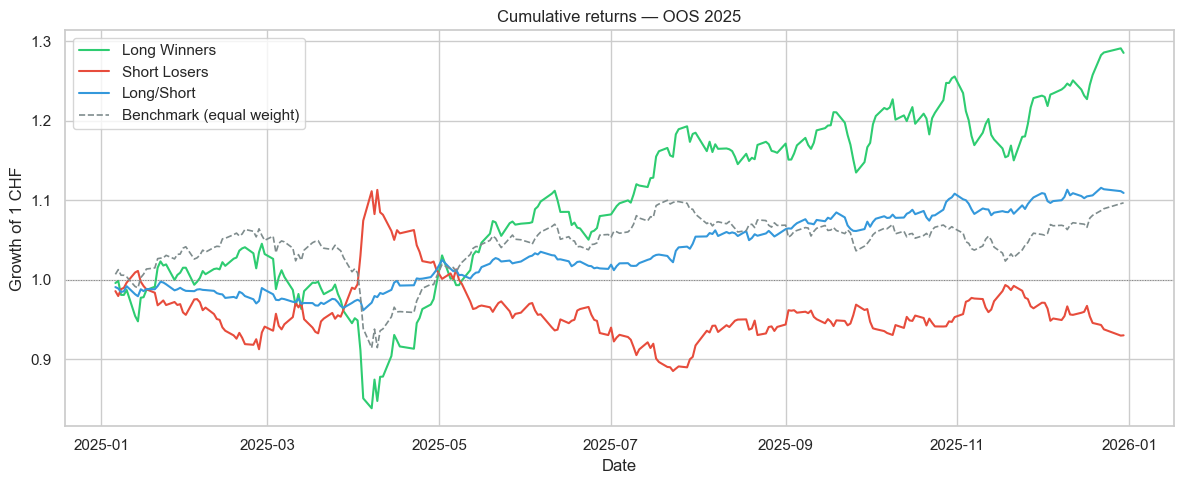

In [33]:
plot_cumulative_returns(result.daily_returns)
plt.show()

## 7 — OOS Klassifikation: Confusion Matrix & Report

              precision    recall  f1-score   support

      Losers       0.34      0.35      0.35        34
      Steady       0.56      0.68      0.61        68
     Winners       0.42      0.24      0.30        34

    accuracy                           0.49       136
   macro avg       0.44      0.42      0.42       136
weighted avg       0.47      0.49      0.47       136



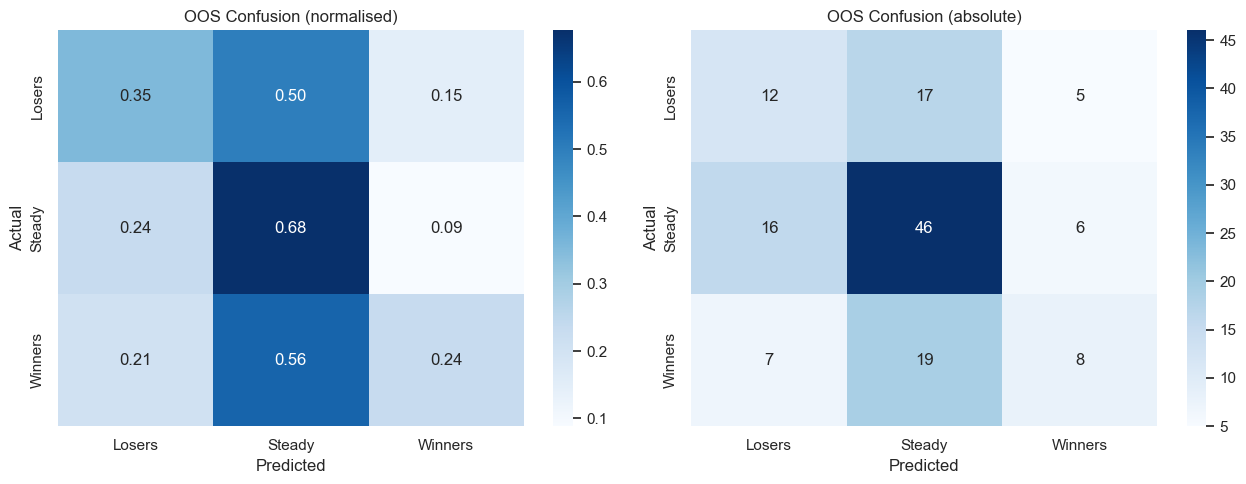

In [34]:
print(result.classification["report_str"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_oos_confusion_matrix(result.classification, title="OOS Confusion (normalised)", normalize=True, ax=axes[0])
plot_oos_confusion_matrix(result.classification, title="OOS Confusion (absolute)", normalize=False, ax=axes[1])
plt.tight_layout()
plt.show()

## 8 — Hit-Rate pro Gruppe

### Hold-out (In-Sample) vs. OOS — Fehlerstruktur

Die **Hold-out-Matrix** stammt aus Notebook 05 (25 % Test-Split innerhalb der Q1-2024-Labels). Die **OOS-Matrix** vergleicht Vorhersagen mit den tatsächlichen 2025-Perzentil-Gruppen. Unterschiedliche Fehlerverteilungen deuten auf Regimewechsel oder Überanpassung hin.

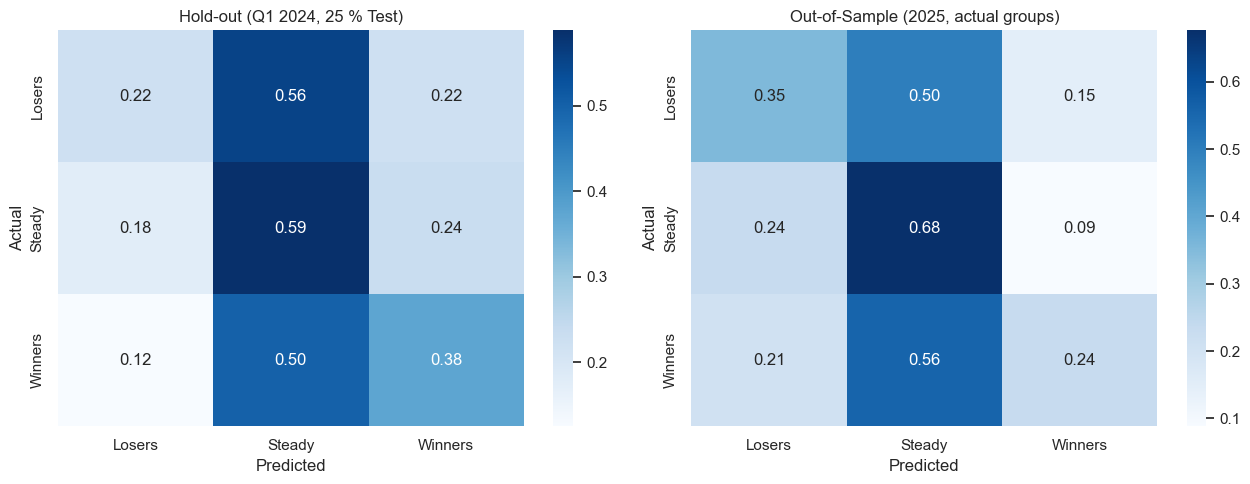

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_confusion_matrix(
    train_result.holdout_metrics,
    train_result.class_names,
    title="Hold-out (Q1 2024, 25 % Test)",
    normalize=True,
    ax=axes[0],
)
plot_oos_confusion_matrix(
    result.classification,
    title="Out-of-Sample (2025, actual groups)",
    normalize=True,
    ax=axes[1],
)
plt.tight_layout()
plt.show()

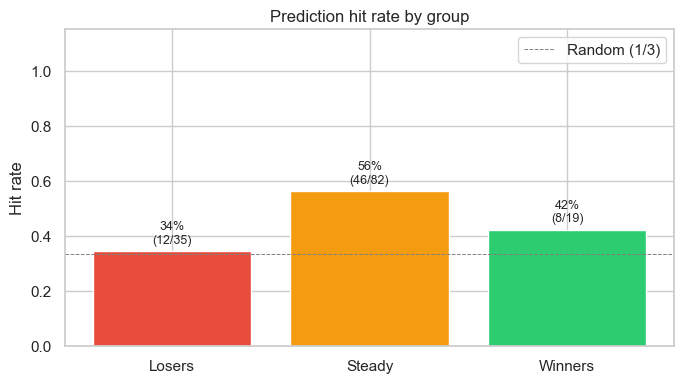


Losers:
  Predicted: 35, Correct: 12, Hit rate: 34.3%
  Actual distribution: {'Steady': 16, 'Losers': 12, 'Winners': 7}

Steady:
  Predicted: 82, Correct: 46, Hit rate: 56.1%
  Actual distribution: {'Steady': 46, 'Winners': 19, 'Losers': 17}

Winners:
  Predicted: 19, Correct: 8, Hit rate: 42.1%
  Actual distribution: {'Winners': 8, 'Steady': 6, 'Losers': 5}


In [36]:
plot_hit_rates(result.hit_rates)
plt.show()

for group, info in result.hit_rates.items():
    print(f"\n{group}:")
    print(f"  Predicted: {info['n_predicted']}, Correct: {info['n_correct']}, Hit rate: {info['hit_rate']:.1%}")
    print(f"  Actual distribution: {info['actual_distribution']}")

## 9 — Vergleich: In-Sample vs Out-of-Sample

Zentrale Frage: Generalisiert das Modell oder liegt Overfitting vor?
- Wenn In-Sample gut, Out-of-Sample schlecht → Overfitting oder Regime-Wechsel
- Wenn beide gut → robustes Signal
- Wenn beide schlecht → Features nicht prädiktiv genug

,In-Sample,Out-of-Sample,Delta
metric,,,
accuracy,0.441176,0.485294,0.044118
f1_macro,0.391721,0.421015,0.029294
f1_weighted,0.431411,0.469095,0.037684


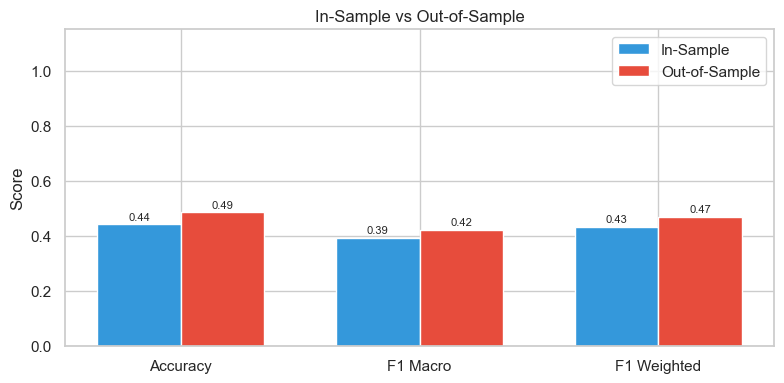

In [37]:
comparison = compare_insample_oos(train_result.holdout_metrics, result.classification)
display(comparison)

plot_insample_vs_oos(comparison)
plt.show()

## 10 — Predicted vs Actual: Detail-Tabelle

In [38]:
detail = pd.DataFrame({
    "predicted": result.predictions,
    "actual": result.actual_groups,
    "return_2025": result.actual_returns,
}).dropna()

detail["correct"] = detail["predicted"] == detail["actual"]
detail = detail.sort_values("return_2025", ascending=False)

print(f"Korrekt klassifiziert: {detail['correct'].sum()} / {len(detail)} ({detail['correct'].mean():.1%})")
print(f"\n=== Top 10 (höchste Returns) ===")
display(detail.head(10))

print(f"\n=== Bottom 10 (niedrigste Returns) ===")
display(detail.tail(10))

Korrekt klassifiziert: 66 / 136 (48.5%)

=== Top 10 (höchste Returns) ===


,predicted,actual,return_2025,correct
IDIA.SW,Winners,Winners,3.346272,True
NWRN.SW,Winners,Winners,1.707151,True
IMPN.SW,Losers,Winners,1.432432,False
CICN.SW,Losers,Winners,1.116667,False
HUBN.SW,Steady,Winners,0.930667,False
UBXN.SW,Losers,Winners,0.812081,False
ZEHN.SW,Winners,Winners,0.770563,True
GAM.SW,Losers,Winners,0.649775,False
COPN.SW,Losers,Winners,0.638629,False
JFN.SW,Steady,Winners,0.540948,False



=== Bottom 10 (niedrigste Returns) ===


,predicted,actual,return_2025,correct
TECN.SW,Steady,Losers,-0.363861,False
SIGN.SW,Steady,Losers,-0.375207,False
SWTQ.SW,Steady,Losers,-0.391827,False
KOMN.SW,Losers,Losers,-0.445502,True
CALN.SW,Steady,Losers,-0.485678,False
ARBN.SW,Steady,Losers,-0.523551,False
LEHN.SW,Losers,Losers,-0.600812,True
ORON.SW,Losers,Losers,-0.665437,True
ROSE.SW,Winners,Losers,-0.701005,False
RIEN.SW,Steady,Losers,-0.962922,False


## Zusammenfassung

| Schritt | Ergebnis |
|---|---|
| Universum | SPI Extra + Liquiditätsfilter (wie Notebook 05) |
| Feature-Shift | Q4 2024 Features (Cutoff `2024-12-31`) |
| Prediction | `final_classifier.joblib` (TrainResult) auf OOS-Featurematrix |
| Strategien | Long Winners, Long/Short, Equal-Weight-Benchmark |
| Klassifikation | Accuracy, F1, OOS-Confusion vs. 2025-Perzentil-Gruppen |
| Fehlerstruktur | Hold-out-Matrix (Q1 2024) vs. OOS-Matrix (2025) |
| Hit-Rate | Pro vorhergesagter Gruppe: Trefferquote, Verteilung der tatsächlichen Klassen |
| In-Sample vs OOS | Hold-out-Metriken vs. OOS (`compare_insample_oos`) |